In [2]:
import cv2
import numpy as np
import imutils
from matplotlib import pyplot as plt

More tutorials on opencv can be found:

https://docs.opencv.org/master/d2/d96/tutorial_py_table_of_contents_imgproc.html

# Image input and initial processing
Load the input image (whose path was supplied via command line argument) and display the image to our screen:

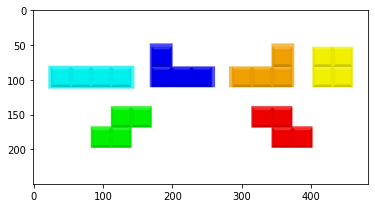

In [3]:
path = "C:/Users/peisz/OneDrive/Documents/Egyetem/DTU/3rd semester/PAS/Week 1/"
bgr_img = cv2.imread(path + "tetris_blocks.png")
b,g,r = cv2.split(bgr_img)       # get b,g,r
image = cv2.merge([r,g,b])
plt.imshow(image)

Convert the image to grayscale:

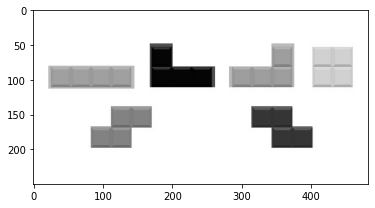

In [ ]:
# Convert an image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
plt.imshow(gray, cmap = 'gray')

# Advanced processing
Apply edge detection, so we can find the outlines of objects in images:


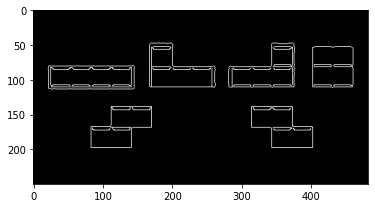

In [ ]:
# Apply Canny edge detection to an image
# cv2.Canny(image, threshold1, threshold2, ...) image should be grayscale, threshold1 - first hysteresis threshold, anything below that gradient value is not an edge,
# output - binary image with edges as 255
# threshold2 - second hysteresis threshold, anything above this gradient value is an edge (strong edge) edges between the two thresholds (weak edges) are only kept if they're connected to strong edges
# common heuristic: threshold1 ≈ 0.4–0.5 × threshold2
# Otherwise:
# First adjust threshold2(high): If you see too few edges => decrease threshold2, if you see too many edges => increase threshold2
# Then adjust threshold1(low): If edges look broken or disconnected => increase threshold1 a little or decrease threshold2 (so the gap between them is smaller),
# If edges look thick / fuzzy or many weak noisy edges are included => increase threshold1.

# In the original Canny algorithm the first step is to blur the image but the OpenCV implementation doesn't include this
# so it is advised to blur the image before running Canny (especially if it is noisy)
edged = cv2.Canny(gray, 30, 150)
plt.imshow(edged, cmap='gray')

Threshold the image by setting all pixel values equal to or less than 225 to 255 (white; foreground): $x \le 225 \rightarrow x = 255$ and all pixel values greater than 225 to 0 (black; background): $x \gt 225 \rightarrow x=0$

Thereby we are segmenting the image.

Both the threshold (e.g. 225 in our case) and the value for pixels less than the threshold in the resulting image (255 in our case) can be tweaked.

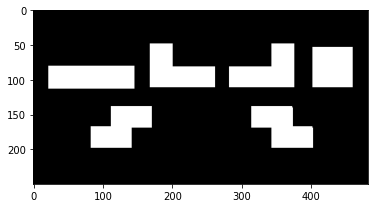

In [ ]:
# Thresholding an image
threshold = 225 # The actual threshold everything below this will be 0 and everything above this will be assigned the threshold_value (p > threshold => p = threshold,
# p <= threshold => p = 0)
threshold_value = 255

# retval, dst = cv2.threshold(src, thresh, maxval, type) src - the (grayscale) image to be thresholded, thresh - threshold value, maxval - value to assign to pixels that pass the test
# type - defines the rule e.g. THRESH_BINARY (normal as explained above), THRESH_BINARY_INV (the inversion of the rule explained above, so if p > threshold => p = 0)
thresh = cv2.threshold(gray, threshold, threshold_value, cv2.THRESH_BINARY_INV)[1]
plt.imshow(thresh, cmap='gray')

Find contours (i.e., outlines) of the foreground objects in the thresholded image:

In [ ]:
# Find contours on a thresholded image
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
output = image.copy()

Loop over the contours:

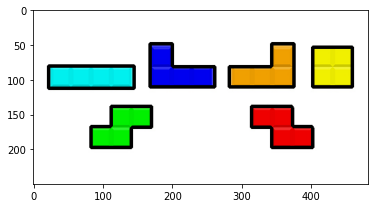

In [8]:
for c in cnts:
    # draw each contour on the output image with a 3px thick black outline
    cv2.drawContours(output, [c], -1, (0, 0, 0), 3)
    
plt.imshow(output)

Draw the total number of contours found in purple:

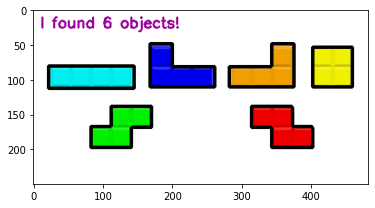

In [9]:
text = "I found {} objects!".format(len(cnts))
cv2.putText(output, text, (10, 25),  cv2.FONT_HERSHEY_SIMPLEX, 0.7, (155, 0, 155), 2)
plt.imshow(output)

We apply erosions to reduce the size of foreground objects:

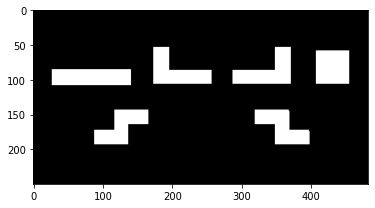

In [18]:
mask = thresh.copy()

# cv2.erode(src, kernel, iterations)
# src: input image; kernel: structuring element (if None, a standard 3x3 rectangular kernel is used);
# iterations: number of times the erosion is applied.
# Erosion works like a local minimum filter. It computes a local minimum over the area of the kernel.
# A pixel in the original image (either 1 or 0) will be considered 1 only if all the pixels under the kernel are 1, otherwise it is eroded (made to 0).
# This "shrinks" the white foreground regions and is useful for removing small white noise (speckles).
mask = cv2.erode(mask, None, iterations = 5)
plt.imshow(mask, cmap = 'gray')

Similarly, dilations can increase the size of the ground objects:

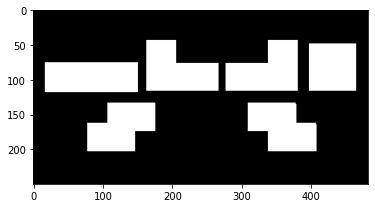

In [19]:
mask = thresh.copy()

# cv2.dilate(src, kernel, iterations)
# src: input image; kernel: structuring element; iterations: number of times dilation is applied.
# Dilation is the opposite of erosion; it works like a local maximum filter.
# If at least one pixel under the kernel is '1' (white), the pixel element being updated becomes '1'.
# This increases the white region in the image or size of the foreground object.
# It is often used after erosion to join broken parts of an object that might have been separated during noise removal.
mask = cv2.dilate(mask, None, iterations = 5)
plt.imshow(mask, cmap='gray')

A typical operation we may want to apply is to take our mask and apply a bitwise `AND` to our input image, keeping only the masked regions:

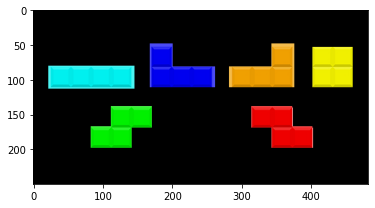

In [ ]:
mask = thresh.copy()

# cv2.bitwise_and(src1, src2, mask)
# src1, src2: input arrays (images); mask: operation mask (8-bit single channel array).
# This function calculates the per-element bit-wise conjunction of two arrays:
# dst(I) = src1(I) AND src2(I) if mask(I) != 0.
# Since src1 and src2 are the same ('image'), the AND operation doesn't change the pixel color itself.
# However, the 'mask' argument ensures that the operation is only performed where the mask is non-zero (white).
# Where the mask is 0 (black), the output pixel is automatically set to 0.
# This effectively cuts out the object defined by the white area of the mask.
output = cv2.bitwise_and(image, image, mask=mask)
plt.imshow(output)

# Exercise 2
1. Can you remove the yellow square from the image?
2. Go through the tutoria, but with the `spheres.png` image. (replace `tetris_blocks.png` with `spheres.png`)
3. Tweak the parameters of the thresholding. Can you threshold all the spheres?
4. Can you remove the red sphere?
5. Can you remove the green sphere?

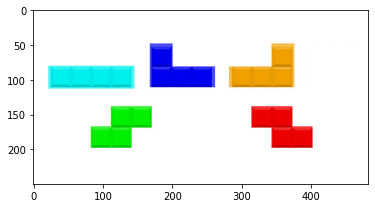

In [20]:
image_yellow = image.copy()

# Manually iterate over every pixel in the image to remove a specific region.
# shape[0] is the height (number of rows), shape[1] is the width (number of columns).
# Note: In Python/OpenCV, images are accessed as matrices: image[y, x] or image[row, col].
# This approach of looping through every pixel is computationally expensive (slow) in Python 
# compared to NumPy slicing (e.g., image[50:120, 400:500] = 255), but it demonstrates the logic clearly.
for h in range(image_yellow.shape[0]):
    for w in range(image_yellow.shape[1]):
        # Define the Region of Interest (ROI) using hardcoded coordinates.
        # We check if the current pixel's height (h) and width (w) fall within the bounding box of the yellow square.
        # Top-left corner approx (w=400, h=50) and Bottom-right corner approx (w=500, h=120).
        if h > 50 and h < 120 and w > 400 and w < 500:
            # If the pixel is inside the box, we set its color values to 255.
            # Setting all 3 channels (0, 1, 2) to 255 results in pure White.
            # Effectively, this "erases" the yellow square by painting over it with the background color (assuming white background).
            image_yellow[h, w, 0] = 255
            image_yellow[h, w, 1] = 255
            image_yellow[h, w, 2] = 255

plt.imshow(image_yellow)

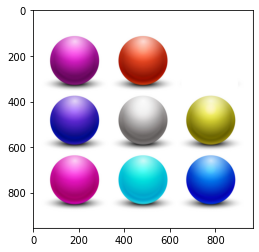

In [ ]:
# Load the spheres image for the second part of the exercise
# Ensure the path variable handles the string concatenation correctly (as fixed previously)
bgr_img2 = cv2.imread(path + "spheres.png")

# Iterate over the image dimensions again to locate and remove the Red Sphere.
for h in range(bgr_img2.shape[0]):
    for w in range(bgr_img2.shape[1]):
        # The coordinates here ($50 < h < 360$ and $650 < w < 900$) correspond to the location of the red sphere.
        # This acts as a manual spatial filter: only pixels within this coordinate range are modified.
        if h > 50 and h < 360 and w > 650 and w < 900:
            # Overwrite the pixel value with white (255, 255, 255).
            # Channel 0, 1, and 2 correspond to Blue, Green, Red in OpenCV (BGR) or Red, Green, Blue in Matplotlib (RGB).
            # Since we set all of them to the max value (255), the result is white regardless of the color space.
            bgr_img2[h, w, 0] = 255
            bgr_img2[h, w, 1] = 255
            bgr_img2[h, w, 2] = 255

# Display the modified image where the red sphere should now be a white rectangle
plt.imshow(bgr_img2)